In [2]:
from pathlib import Path

from matplotlib import gridspec
import seaborn as sns
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import DataLoader

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import analysis_utils as au
from src import plot_utils as pu
from src.mod_cog_tasks import *

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
device = get_device()
print(device)

In [2]:
# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  7  8  9 10 11
 12 13 14 15  0]


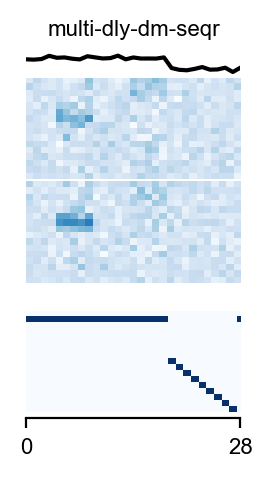

In [3]:
env = multidlydmseqr()

fig = plt.figure(figsize=(2.5, 2), dpi=200)
# fig.suptitle("Task: "+ task_name)
grid_size = 2
#gs = gridspec.GridSpec(14, grid_size, figure=fig)
gs = gridspec.GridSpec(14, grid_size, figure=fig, 
                    left=0.05, right=0.95, top=0.95, bottom=0.05, 
                    wspace=0.1, hspace=0.1)

noise_sigma = 0.1


fontsize=8
env_idx = 1 
env.new_trial()
ob = env.ob
noise = np.random.normal(loc=0.0, scale=noise_sigma, size=ob.shape)
ob = ob + noise

gt = env.gt
seq_len = ob.shape[0]

ax1 = fig.add_subplot(gs[0, env_idx])
ax2 = fig.add_subplot(gs[1:5, env_idx])
ax3 = fig.add_subplot(gs[5:9, env_idx])
ax4 = fig.add_subplot(gs[10:,env_idx])

# Plot fixation
ax1.plot(ob[:, 0], "k")
ax1.set_xlim(0, seq_len-1)
ax1.set_ylim(-noise_sigma*5, 1+noise_sigma*5)
ax1.set_title("multi-dly-dm-seqr", fontsize=fontsize)
ax1.set_axis_off()

# Inputs rings 
im1  = ax2.imshow(ob[:, 1:17].T, aspect="auto", cmap="Blues", vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)
im2 = ax3.imshow(ob[:, 17:34].T, aspect="auto", cmap="Blues", vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)

#im1.colo

for ax in [ax2, ax3]:
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])
    ax.set_axis_off()

#print(gt.shape)
#ax4.plot(gt[:])
# output ring
print(gt)
imy = ax4.imshow(np.eye(17)[1+gt].T, aspect="auto", cmap="Blues")
# ax4.set_ylim(-0.5, env.action_space.n)
ax4.set_xlim(0,seq_len-1)
ax4.set_yticklabels([])
ax4.set_yticks([])
x_limits = ax4.get_xlim()
sns.despine(ax=ax4, left=True, right=True, top=True, bottom=False, offset=2)
# Set x-axis ticks to be at the start and end of the x-axis limits
ax4.set_xticks([x_limits[0], x_limits[1]])
ax4.tick_params(axis='x', which='major', labelsize=fontsize)  # for major ticks

# In the MultSen DM task, the correct response should be made to the stimulus that has a stronger combined strength in modalities 1 and 2

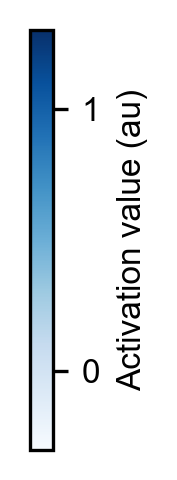

In [31]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Create a figure
fig = plt.figure(figsize=(1.5, 2), dpi=300)
# Define a colormap and normalization
colormap = cm.Blues
norm = mcolors.Normalize(vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)
# Create a ScalarMappable to map values to colors
scalar_mappable = cm.ScalarMappable(norm=norm, cmap=colormap)
# Add an axes for the color bar manually

orientation = "vertical"
if orientation == "horizontal":
    cax = fig.add_axes([0.85, 0.15, 0.7, 0.05])  # [left, bottom, width, height]
else:
    cax = fig.add_axes([0.85, 0.15, 0.05, 0.7])  # [left, bottom, width, height]

# Add the color bar to the figure using the cax axes
cbar = fig.colorbar(scalar_mappable, cax=cax, orientation=orientation)  # 'horizontal' for a horizontal bar
# Set the color bar label
cbar.set_label('Activation value (au)', fontsize=8)
cbar.ax.tick_params(axis='y', labelsize=8) 
cbar.set_ticks([0, 1])  # Set custom tick positions

plt.savefig("figs/mod_cog_dataset/colorbar.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/colorbar.pdf", transparent=True)
plt.show()

In [4]:
## Reach Tasks Family
# 6 Yang 2019 go tasks (_Reach class) 
yang_go_anti = [go(), rtgo(), dlygo(), anti(), rtanti(), dlyanti()]
yang_go_anti_names = ['go', 'rt-go', 'dly-go', 'anti', 'rt-anti', 'dly-anti']

# 4 mod cog interval based offset right and left tasks from the delay anti and go tasks
mc_go_anti_int = [dlygointl(), dlygointr(), dlyantiintl(), dlyantiintr()]
mc_go_anti_int_names = ['dly-go-intl', 'dly-go-intr', 'dly-anti-intl', 'dly-anti-intr']

# 12 mod cog sequence right left from 6 (break into anti and go)
mc_go_seq = [goseql(), goseqr(), dlygoseql(), dlygoseqr(), rtgoseqr(),rtgoseql() ]
mc_anti_seq = [antiseqr(), antiseql(), dlyantiseqr(), dlyantiseql(), rtantiseqr(), rtantiseql()]

mc_go_seq_names= ['go-seql', 'go-seqr', 'dly-go-seql', 'dly-go-seqr', 'rt-go-seqr', 'rt-go-seql']
mc_anti_seq_names = ['anti-seqr', 'anti-seql', 'dly-anti-seqr', 'dly-anti-seql', 'rt-anti-seqr', 'rt-anti-seql']

## Second family of 10 Decision Making tasks (_DMFamily class)
# the DM 1, DM 2, Ctx DM 1, Ctx DM 2 and MultSen DM tasks
yang_dm = [dm1(), dm2(), ctxdm1(), ctxdm2(), multidm()] 
yang_dlydm = [dlydm1(), dlydm2(), ctxdlydm1(), ctxdlydm2(), multidlydm()]
yang_dm_names = ['dm1', 'dm2', 'ctx-dm1', 'ctx-dm2', 'multi-dm']
yang_dlydm_names = ['dly-dm1', 'dly-dm2', 'dly-ctx-dm1', 'dly-ctx-dm2', 'dly-multi-dm']

# 10 mod cog interval offsets from the 5 delay dm tasks 
mc_dmdly_intl = [dlydm1intl(), dlydm2intl(), ctxdlydm1intl(), ctxdlydm2intl(), multidlydmintl()]
mc_dmdly_intr = [dlydm1intr(), dlydm2intr(), ctxdlydm1intr(), ctxdlydm2intr(), multidlydmintr()]
mc_dmdly_intl_names = ['dly-dm1-intl', 'dly-dm2-intl', 'dly-ctx-dm1-intl', 'dly-ctx-dm2-intl', 'dly-multi-dm-intl']
mc_dmdly_intr_names = ['dly-dm1-intr', 'dly-dm2-intr', 'dly-ctx-dm1-intr', 'dly-ctx-dm2-intr', 'dly-multi-dm-intr']

# 20 sequences from the 5 delay dm tasks 5 non delay
mc_dm_seqr = [dm1seqr(), dm2seqr(), ctxdm1seqr(), ctxdm2seqr(), multidmseqr()]
mc_dm_seql = [dm1seql(), dm2seql(), ctxdm1seql(), ctxdm2seql(), multidmseql()]
mc_dmdly_seqr = [dlydm1seqr(), dlydm2seqr(), ctxdlydm1seqr(), ctxdlydm2seqr(), multidlydmseqr()]
mc_dmdly_seql = [dlydm1seql(), dlydm2seql(), ctxdlydm1seql(), ctxdlydm2seql(), multidlydmseql()]

mc_dm_seqr_names = ['dm1-seqr', 'dm2-seqr', 'ctxdm1-seqr', 'ctxdm2-seqr', 'multidm-seqr']
mc_dm_seql_names = ['dm1-seql', 'dm2-seql', 'ctxdm1-seql', 'ctxdm2-seql', 'multidm-seql']
mc_dmdly_seqr_names = ['dly-dm1-seqr', 'dly-dm2-seqr', 'ctx-dly-dm1-seqr', 'ctx-dly-dm2-seqr', 'multi-dly-dm-seqr']
mc_dmdly_seql_names = ['dly-dm1-seql', 'dly-dm2-seql', 'ctx-dly-dm1-seql', 'ctx-dly-dm2-seql', 'multi-dly-dm-seql']

## Matching family
# This family of tasks includes the DMS, DNMS, DMC, DNMC tasks.
yang_match = [dms(), dnms(), dmc(), dnmc()]
yang_match_names = ['dms', 'dnms', 'dmc', 'dnmc']

mc_match_intr =[dmsintr(), dnmsintr(), dnmcintr(), dmcintr()]
mc_match_intl = [dmsintl(), dnmsintl(), dnmcintl(), dmcintl()]

mc_match_intr_names = ['dms-intr', 'dnms-intr', 'dnmc-intr', 'dmc-intr']
mc_match_intl_names = ['dms-intl', 'dnms-intl', 'dnmc-intl', 'dmc-intl']

mc_match_seqr = [dmsseqr(), dnmsseqr(), dnmcseqr(), dmcseqr()]
mc_match_seql = [dmsseql(), dnmsseql(), dnmcseql(), dmcseql()]
mc_match_seqr_names = ['dms-seqr', 'dnms-seqr', 'dnmc-seqr', 'dmc-seqr']
mc_match_seql_names = ['dms-seql', 'dnms-seql', 'dnmc-seql', 'dmc-seql']

n_tasks = len(yang_go_anti)+len(mc_go_anti_int)+len(mc_go_seq)+ len(mc_anti_seq)
n_tasks += len(yang_dm)+len(yang_dlydm) + len(mc_dmdly_intl) + len(mc_dmdly_intr) \
        + len(mc_dm_seqr) + len(mc_dm_seql) + len(mc_dmdly_seqr) + len(mc_dmdly_seql)
print(n_tasks)
n_tasks += len(yang_match) + len(mc_match_intr) + len(mc_match_intl) + len(mc_match_seqr) + len(mc_match_seql)
print(n_tasks)

62
82


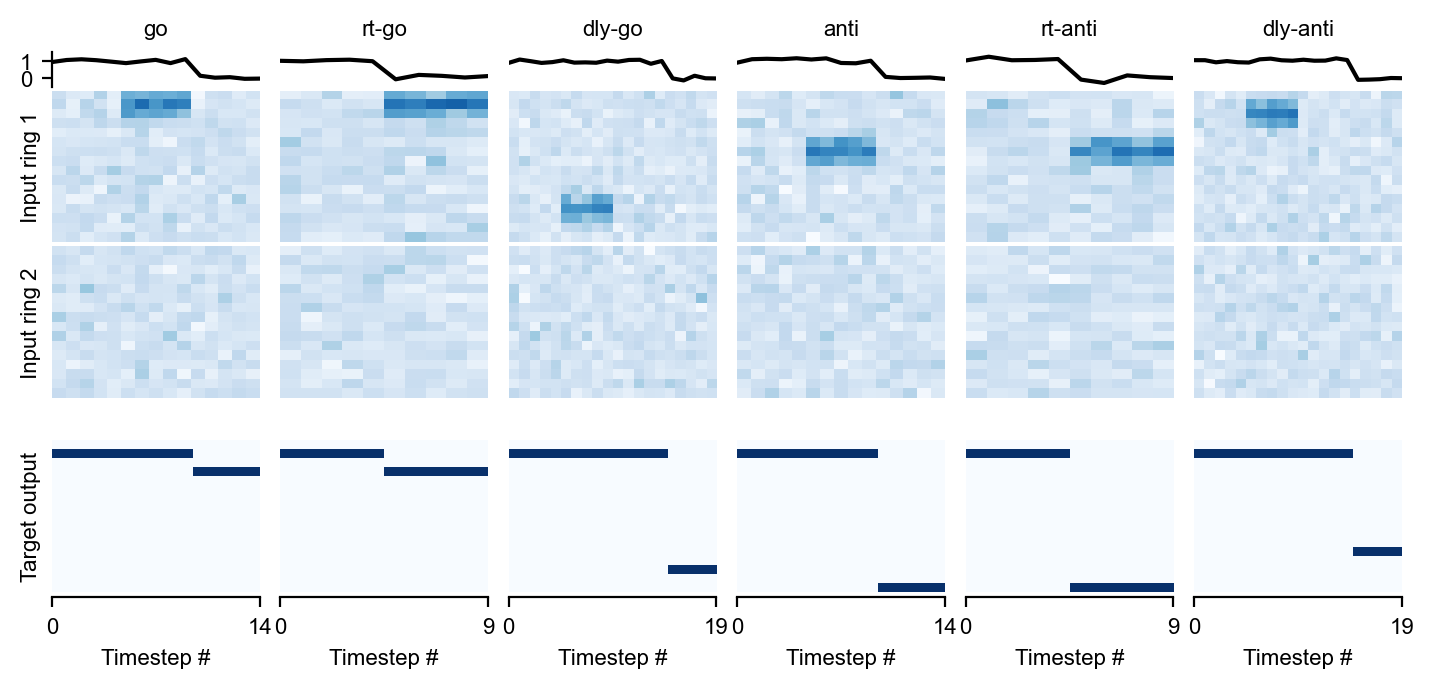

In [11]:
def plot_task_family(tasks, task_names, grid_size = None, fontsize=8):
    fig = plt.figure(figsize=(7.5, 3), dpi=200)
    # fig.suptitle("Task: "+ task_name)
    
    if grid_size is None:grid_size = len(tasks)
    #gs = gridspec.GridSpec(14, grid_size, figure=fig)
    gs = gridspec.GridSpec(14, grid_size, figure=fig, 
                        left=0.05, right=0.95, top=0.95, bottom=0.05, 
                        wspace=0.1, hspace=0.1)

    noise_sigma = 0.1
    #noise_sigma = 0.025

    for env_idx, env in enumerate(tasks):
        env.new_trial()
        ob = env.ob
        noise = np.random.normal(loc=0.0, scale=noise_sigma, size=ob.shape)
        ob = ob + noise
        
        gt = env.gt
        seq_len = ob.shape[0]

        ax1 = fig.add_subplot(gs[0, env_idx])
        ax2 = fig.add_subplot(gs[1:5, env_idx])
        ax3 = fig.add_subplot(gs[5:9, env_idx])
        ax4 = fig.add_subplot(gs[10:,env_idx])

        # Plot fixation
        ax1.plot(ob[:, 0], "k")
        ax1.set_xlim(0, seq_len-1)
        ax1.set_ylim(-noise_sigma*5, 1+noise_sigma*5)
        ax1.set_title(task_names[env_idx], fontsize=fontsize)
            
        # Inputs rings 
        im1  = ax2.imshow(ob[:, 1:17].T, aspect="auto", cmap="Blues", vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)
        im2 = ax3.imshow(ob[:, 17:34].T, aspect="auto", cmap="Blues", vmin=0-noise_sigma*3, vmax=1+noise_sigma*3)

        imy = ax4.imshow(np.eye(17)[1+gt].T, aspect="auto", cmap="Blues")
        
        if env_idx == 0:
            ax1.get_xaxis().set_visible(False)
            ax1.spines['top'].set_visible(False)
            ax1.spines['right'].set_visible(False)
            #ax1.spines['left'].set_visible(False)
            ax1.spines['bottom'].set_visible(False)
            ax1.tick_params(axis='y', labelsize=8) 
            
            ax2.set_ylabel("Input ring 1", fontsize=8)
            ax2.set_yticks([]) 
            ax2.set_xticks([]) 
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)
            ax2.spines['left'].set_visible(False)
            ax2.spines['bottom'].set_visible(False)
            
            ax3.set_ylabel("Input ring 2", fontsize=8)
            ax3.set_yticks([]) 
            ax3.set_xticks([]) 
            ax3.spines['top'].set_visible(False)
            ax3.spines['right'].set_visible(False)
            ax3.spines['left'].set_visible(False)
            ax3.spines['bottom'].set_visible(False)
            
            ax4.set_ylabel("Target output", fontsize=8)

            
        else:
            for ax in [ax1, ax2, ax3]:
                ax.set_axis_off()
            
        # ax4.set_ylim(-0.5, env.action_space.n)
        ax4.set_xlim(0,seq_len-1)
        ax4.set_yticklabels([])
        ax4.set_yticks([])
        ax4.set_xlabel("Timestep #", fontsize=8)
        x_limits = ax4.get_xlim()
        sns.despine(ax=ax4, left=True, right=True, top=True, bottom=False, offset=2)
        # Set x-axis ticks to be at the start and end of the x-axis limits
        ax4.set_xticks([x_limits[0], x_limits[1]])
        ax4.tick_params(axis='x', which='major', labelsize=fontsize)  # for major ticks

    return fig
fig = plot_task_family(yang_go_anti, yang_go_anti_names, grid_size=len(yang_go_anti))
plt.savefig("figs/mod_cog_dataset/s1a_yang_go_anti_family.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_yang_go_anti_family.pdf", transparent=True)


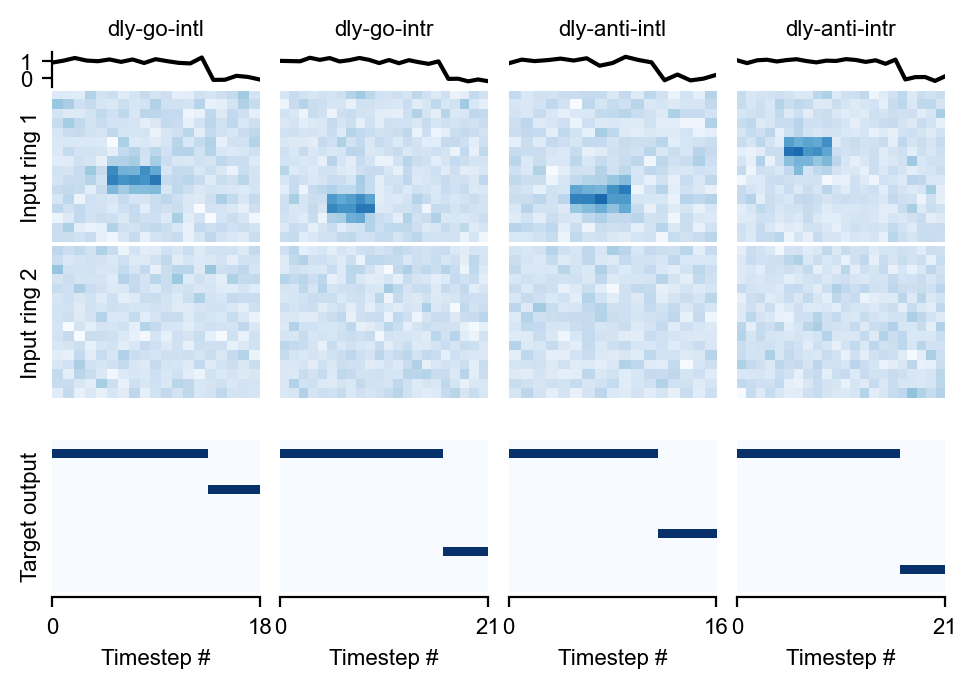

In [32]:
fig = plot_task_family(mc_go_anti_int, mc_go_anti_int_names, grid_size=6)
#plt.savefig("figs/mod_cog_dataset/mc_int.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_mc_go_int.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_mc_go_int.pdf", transparent=True)

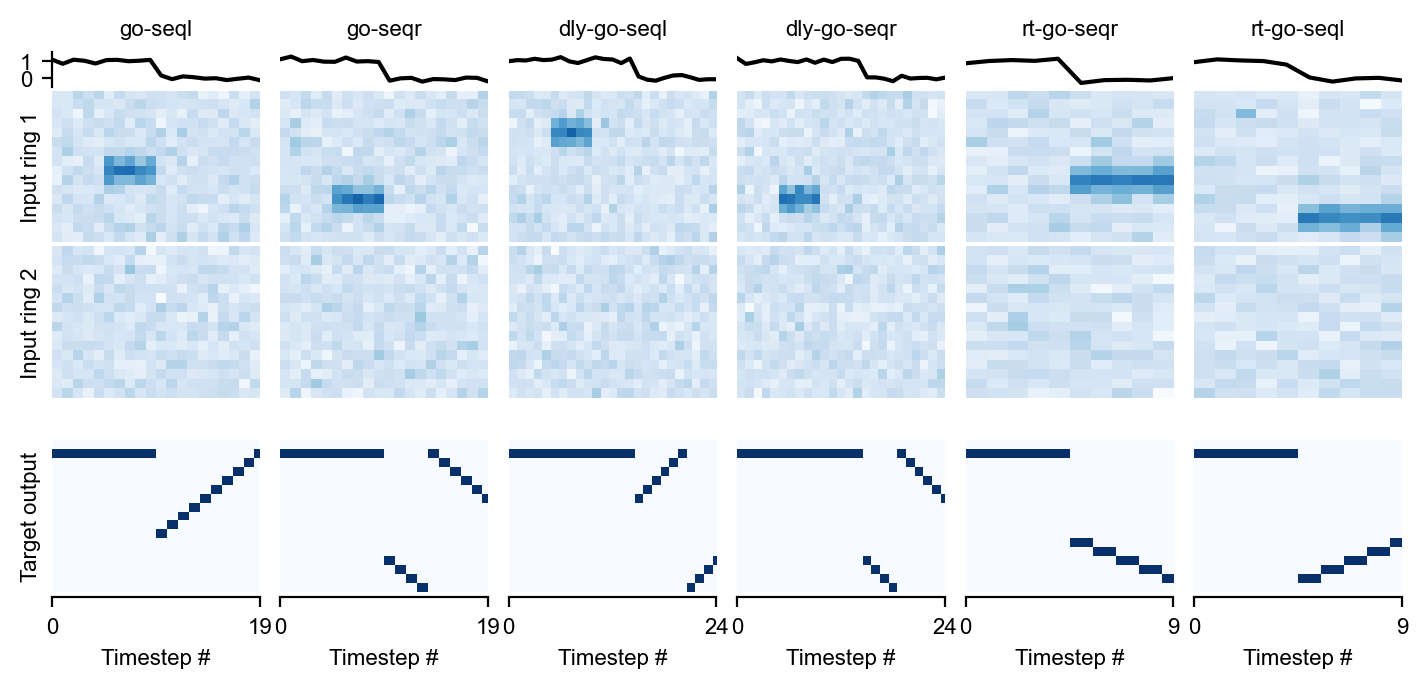

In [33]:
fig = plot_task_family(mc_go_seq, mc_go_seq_names, grid_size=6)
plt.savefig("figs/mod_cog_dataset/mc_go_seq.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_mc_go_seq.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_mc_go_seq.pdf", transparent=True)

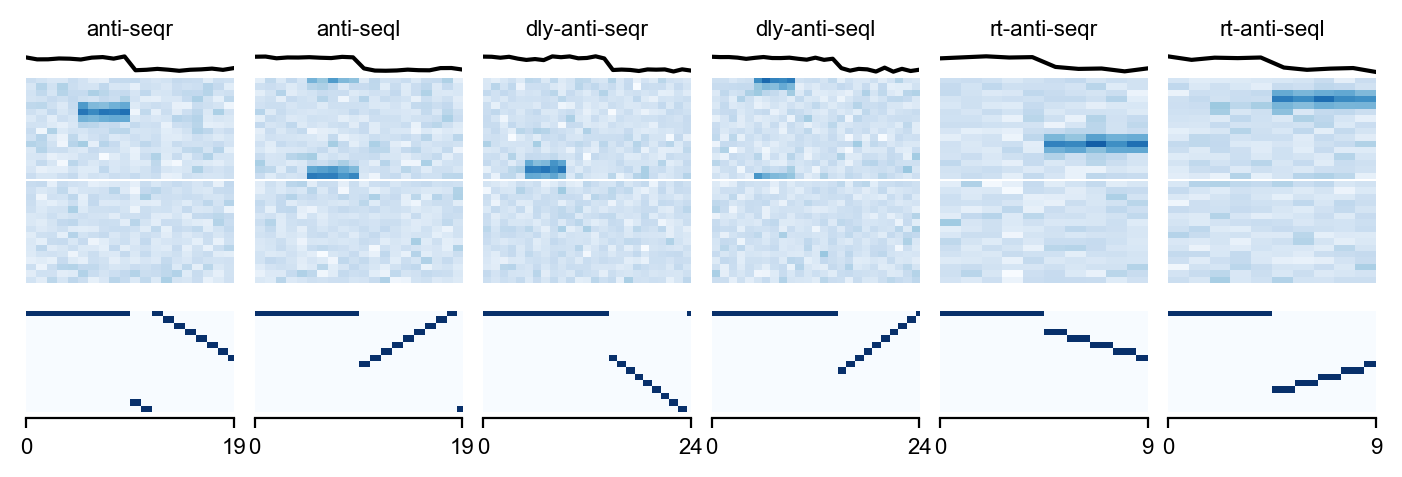

In [9]:
fig = plot_task_family(mc_anti_seq, mc_anti_seq_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/mc_anti_seq.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_mc_anti_int.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1a_mc_anti_int.pdf", transparent=True)

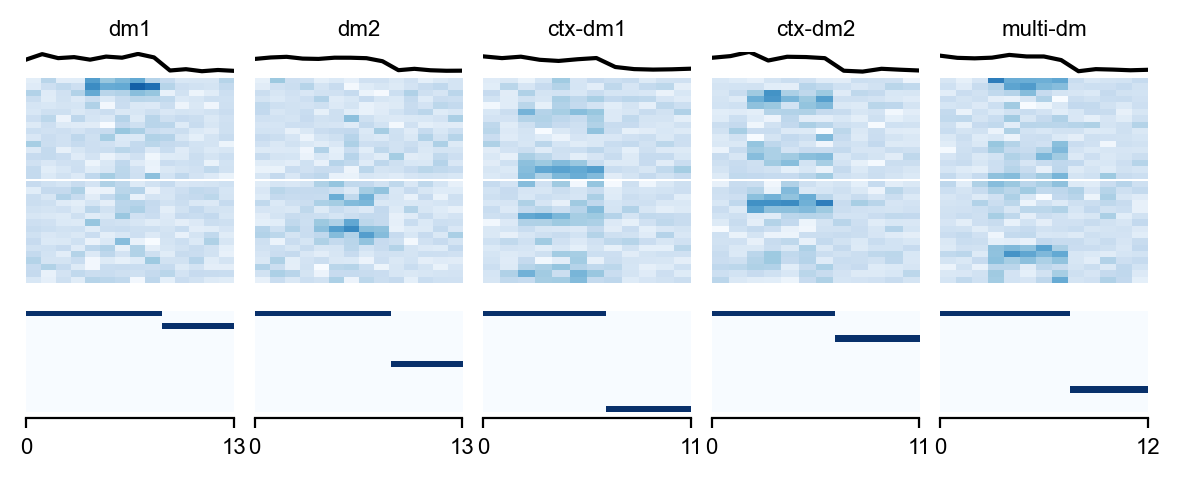

In [13]:
fig = plot_task_family(yang_dm, yang_dm_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/yang_dm.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_yang_dm.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_yang_dm.pdf", transparent=True)

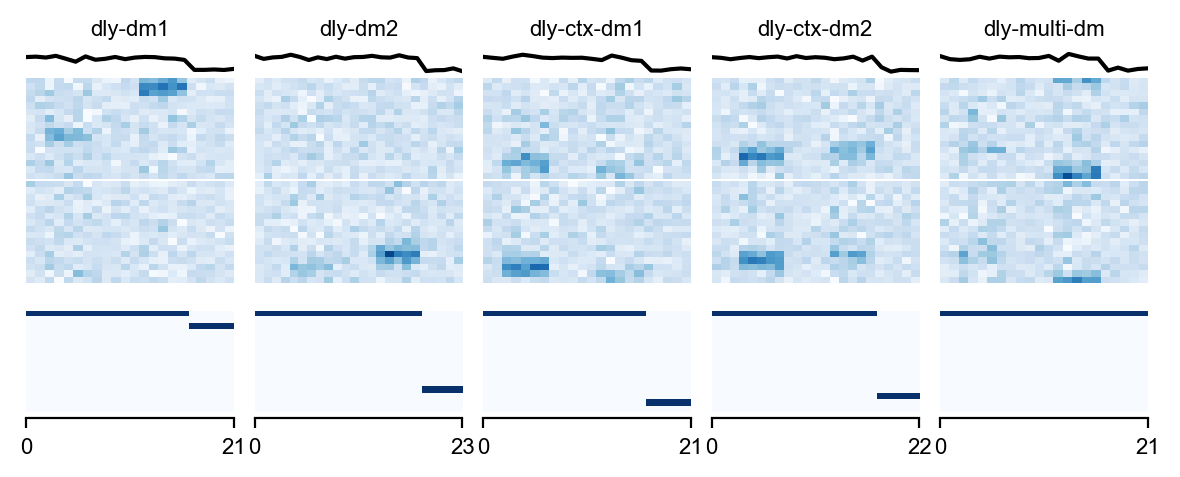

In [14]:
fig = plot_task_family(yang_dlydm, yang_dlydm_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/yang_dlydm.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_yang_dlydm.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_yang_dlydm.pdf", transparent=True)

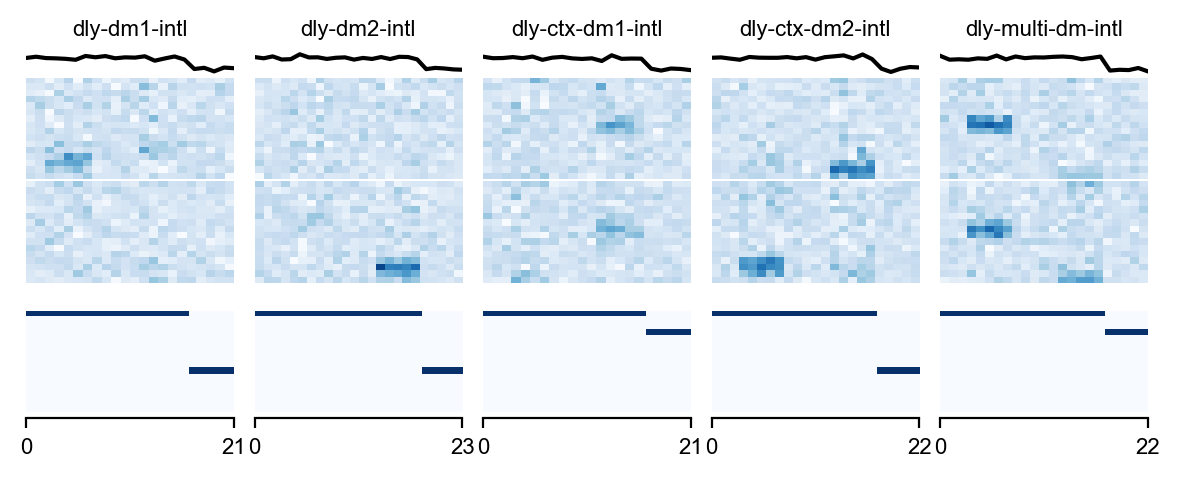

In [15]:
# mod cod integrate tasks
fig = plot_task_family(mc_dmdly_intl, mc_dmdly_intl_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/mc_dmdly_intl.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_int.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_int.pdf", transparent=True)

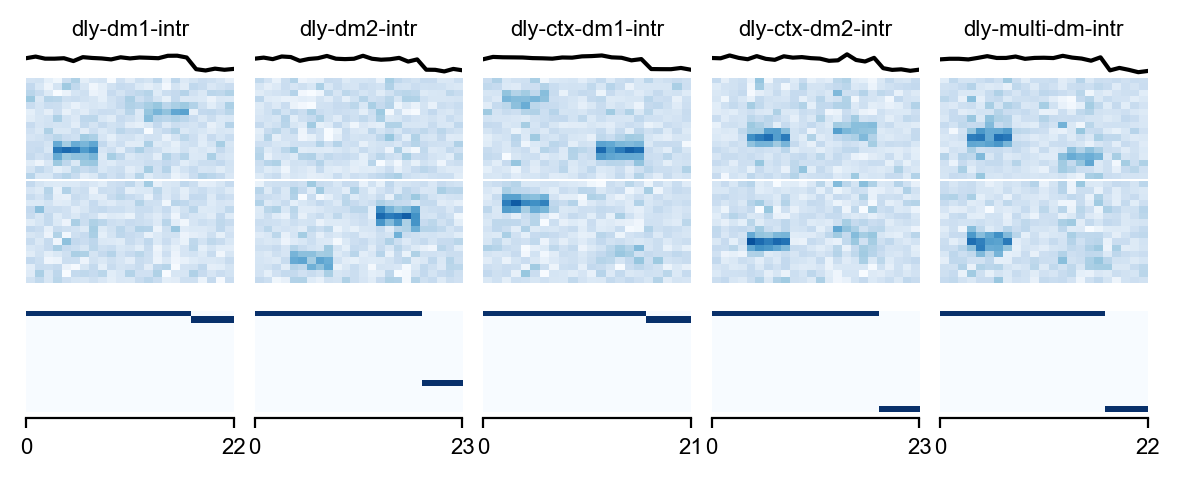

In [17]:
fig = plot_task_family(mc_dmdly_intr, mc_dmdly_intr_names, grid_size=6)
plt.savefig("figs/mod_cog_dataset/mc_dmdly_intr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_intr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_intr.pdf", transparent=True)

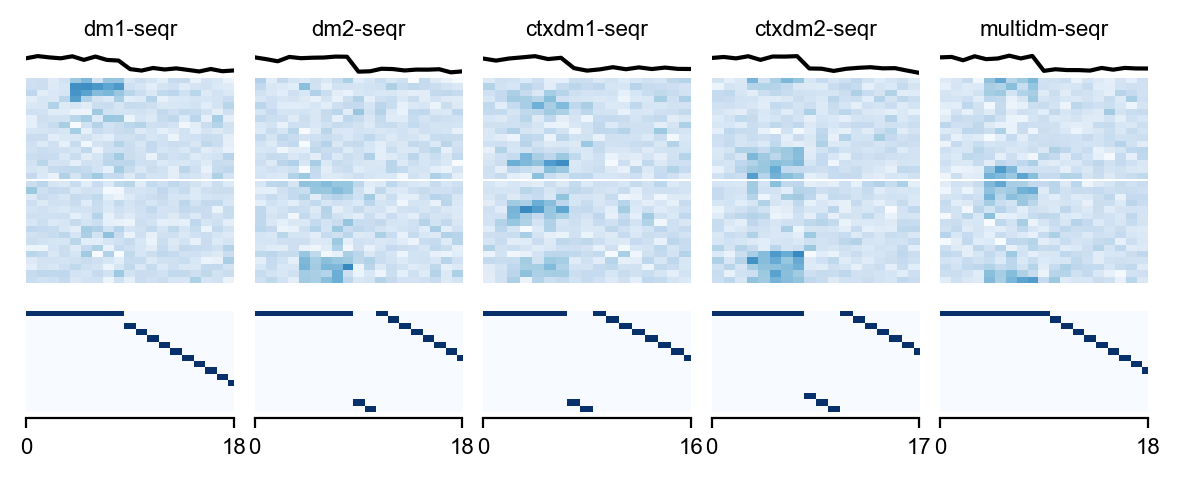

In [19]:
fig = plot_task_family(mc_dm_seqr, mc_dm_seqr_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/mc_dm_seqr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dm_seqr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dm_seqr.pdf", transparent=True)

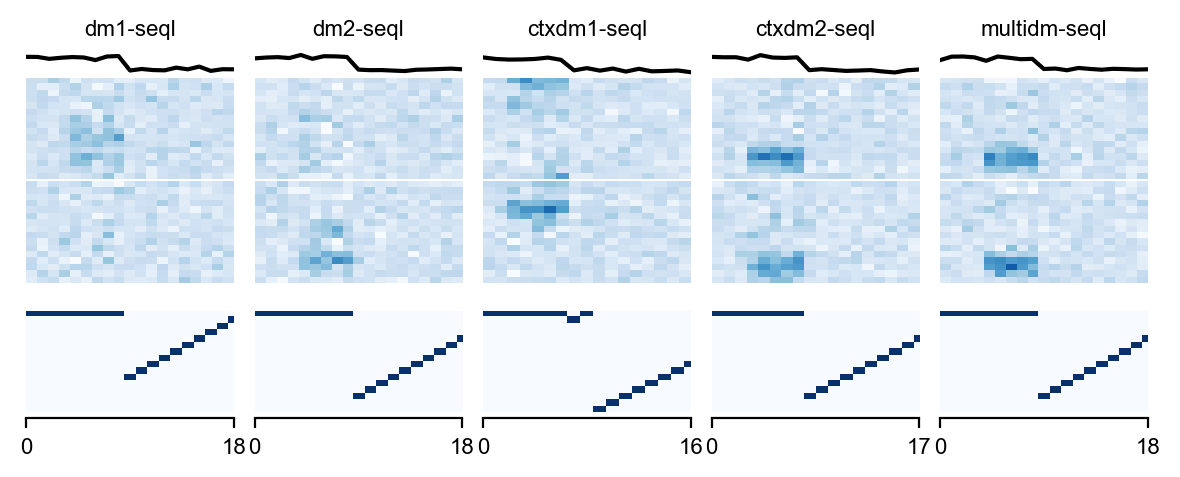

In [21]:
fig = plot_task_family(mc_dm_seql, mc_dm_seql_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/mc_dm_seqr.png", transparent=True)
# plt.savefig("figs/mod_cog_dataset/mc_dm_seqr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dm_seql.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dm_seql.pdf", transparent=True)

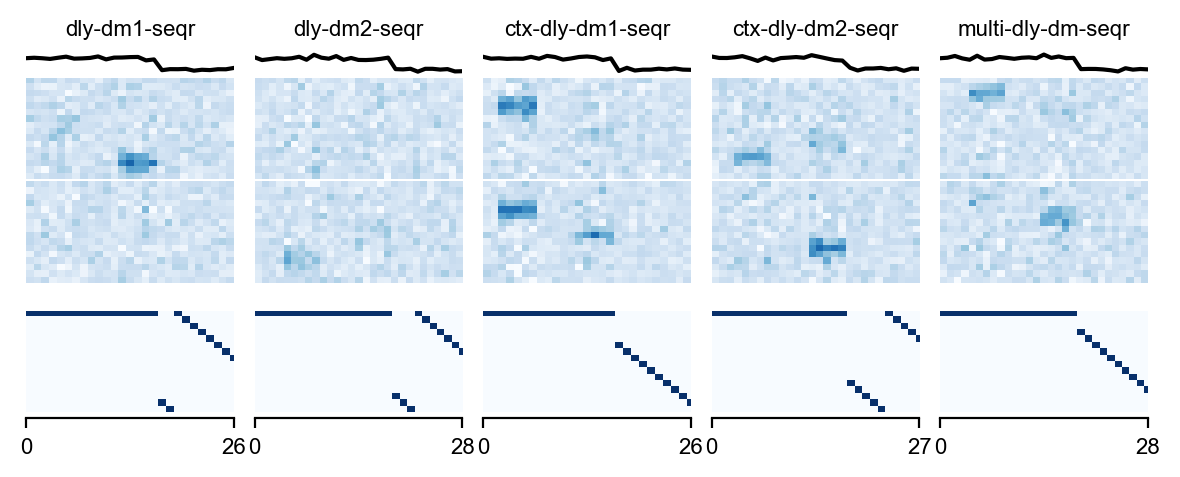

In [22]:
fig = plot_task_family(mc_dmdly_seqr, mc_dmdly_seqr_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/mc_dmdly_seqr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_seqr.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_seqr.pdf", transparent=True)

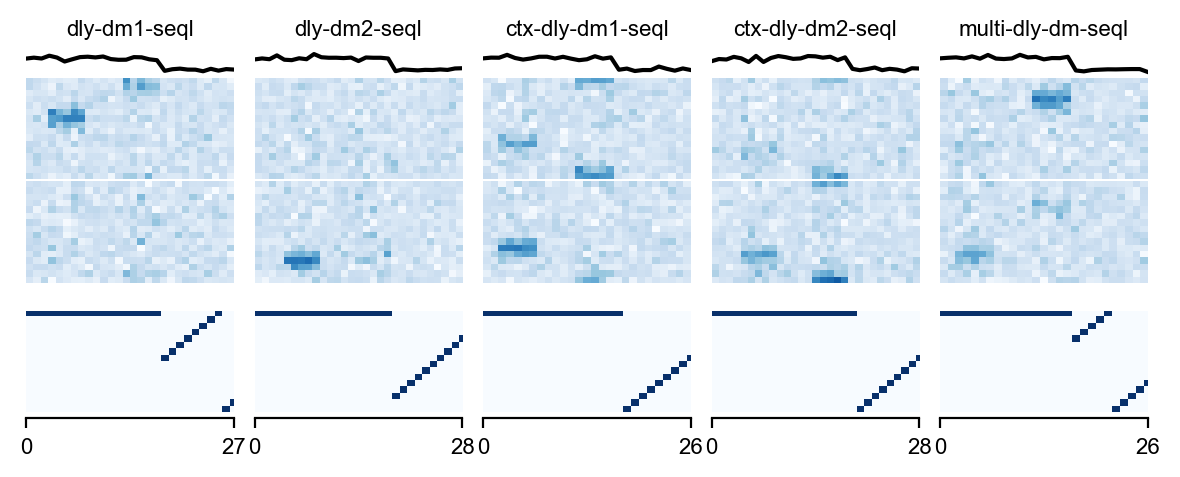

In [23]:
fig = plot_task_family(mc_dmdly_seql, mc_dmdly_seql_names, grid_size=6)
# plt.savefig("figs/mod_cog_dataset/mc_dmdly_seql.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_seql.png", transparent=True)
plt.savefig("figs/mod_cog_dataset/s1b_mc_dmdly_seql.pdf", transparent=True)

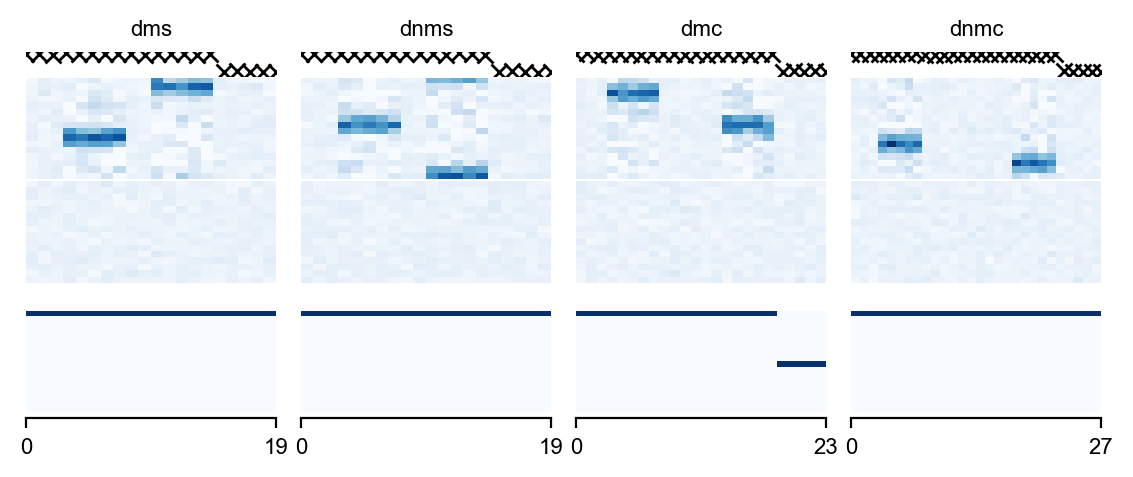

In [112]:
fig = plot_task_family(yang_match, yang_match_names, grid_size=5)
plt.savefig("figs/mod_cog_dataset/yang_match.png", transparent=True)

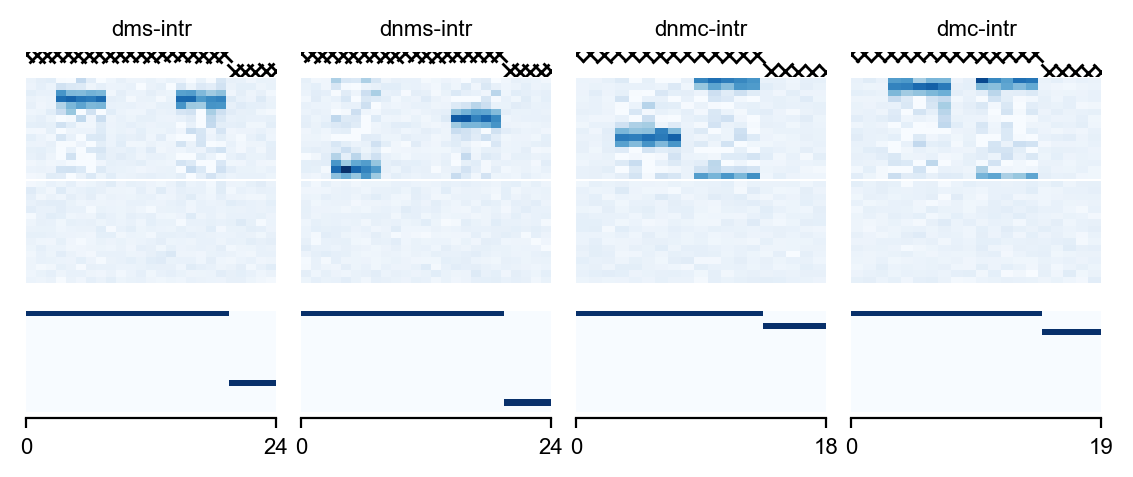

In [113]:
fig = plot_task_family(mc_match_intr, mc_match_intr_names, grid_size=5)
plt.savefig("figs/mod_cog_dataset/mc_match_intr.png", transparent=True)

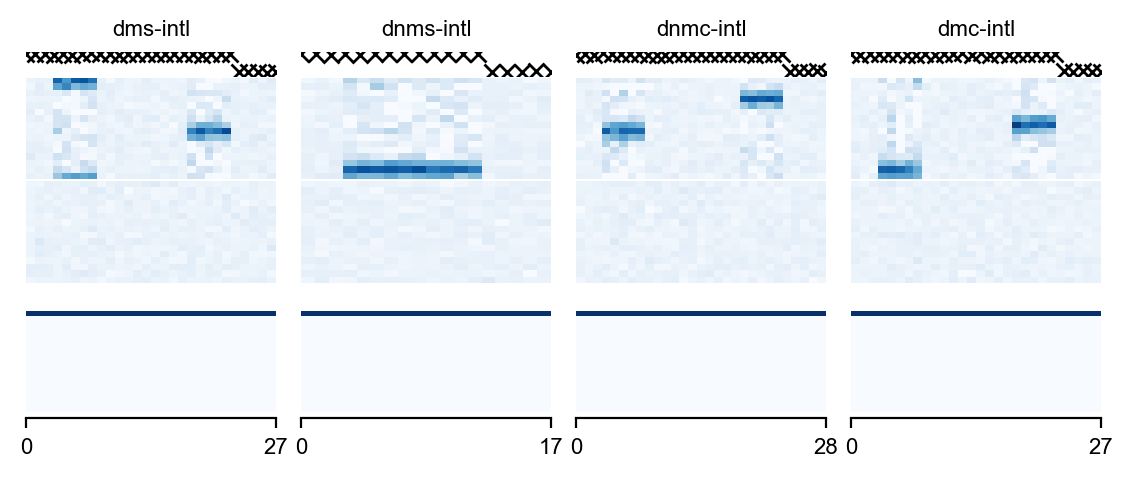

In [ ]:
fig = plot_task_family(mc_match_intl, mc_match_intl_names, grid_size=5)
plt.savefig("figs/mod_cog_dataset/mc_match_intl.png", transparent=True)

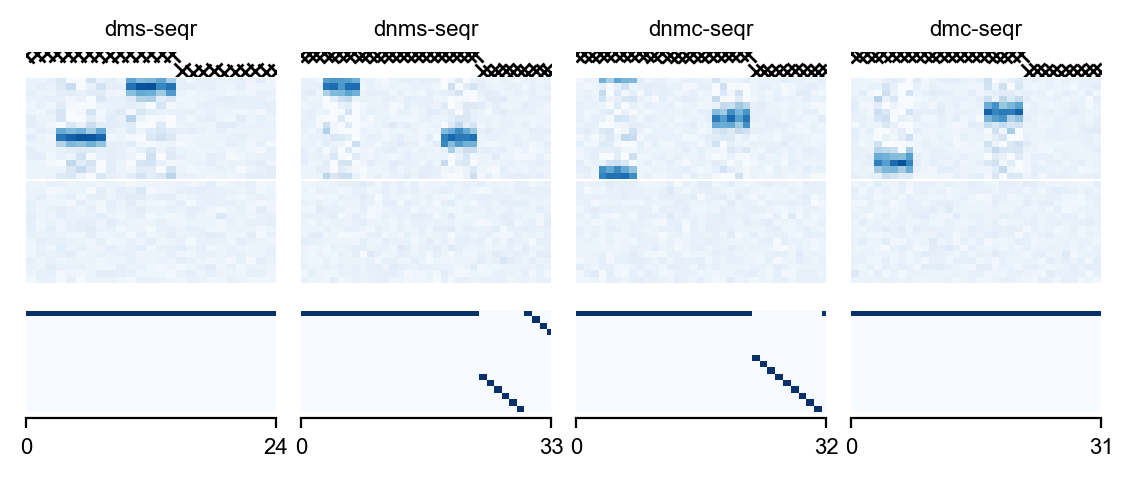

In [115]:
fig = plot_task_family(mc_match_seqr, mc_match_seqr_names, grid_size=5)
plt.savefig("figs/mod_cog_dataset/mc_match_seqr.png", transparent=True)

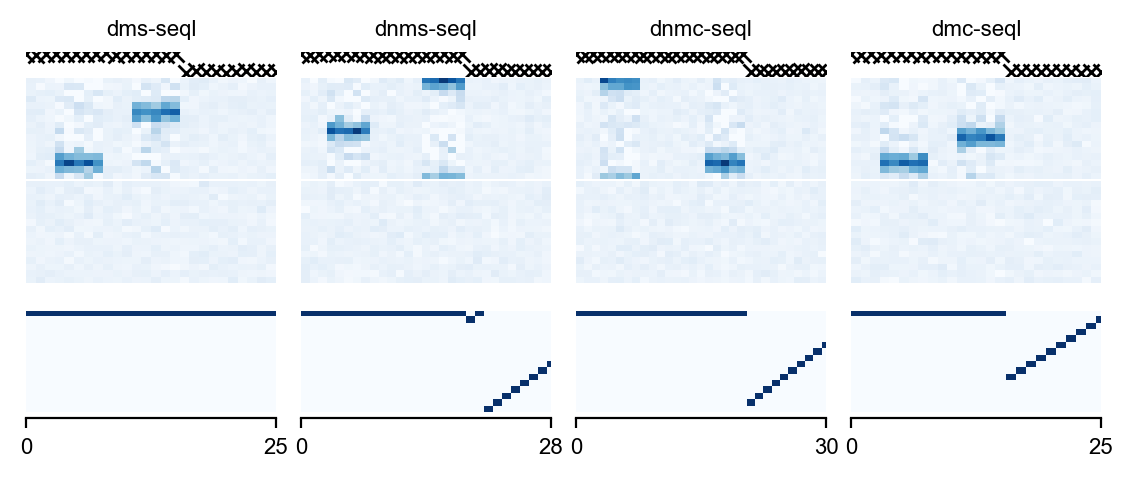

In [ ]:
fig = plot_task_family(mc_match_seql, mc_match_seql_names, grid_size=5)
plt.savefig("figs/mod_cog_dataset/mc_match_seql.png", transparent=True)